In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scanpy as sc
import anndata as ad

import os
import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [2]:
seed = 1234
np.random.seed(seed)

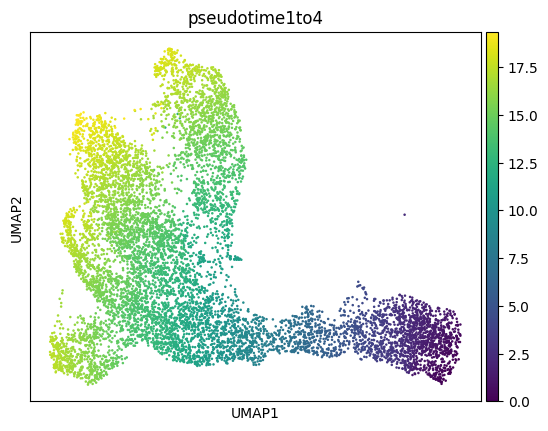

In [3]:
adata_organized = sc.read_h5ad("/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_trajectory_phase_sctie/integration_portal_recover_gene_matrices/adata_integrated_trajectory1to4_recovered_genes.h5ad")
hvg_name = np.load("/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_trajectory_phase_sctie/integration_portal_recover_gene_matrices/hvg_names.npy", allow_pickle=True)
# adata = ad.AnnData(X = adata_organized.obsm["expression_scaled"])
adata = ad.AnnData(X = adata_organized.obsm["expression_log_normalized"])
adata.var.index = list(hvg_name)
adata.obs = adata_organized.obs
adata.obsm["X_umap"] = adata_organized.obsm["X_umap"]
adata.obsm["lowdim_portal"] = adata_organized.obsm["lowdim_portal"]
adata.obsm["X_gene"] = adata.X
sc.pl.umap(adata, color=["pseudotime1to4"])

In [4]:
set(adata.obs["orig.ident"])

{'E14.5_Lung', 'E14.5_pancrease', 'ENS_E14', 'ICN.E14.3'}

/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


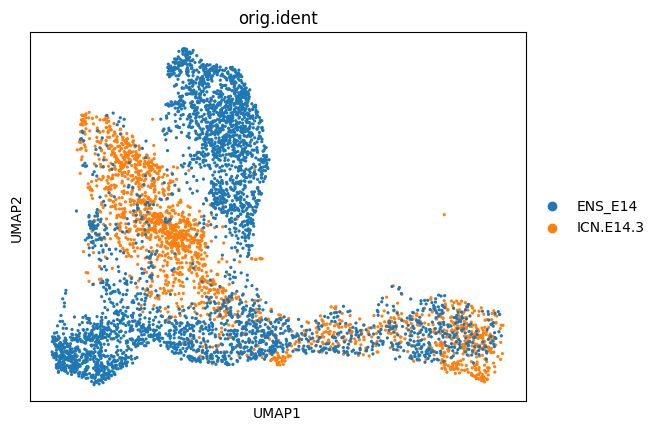

In [5]:
organ_1 = "ICN.E14.3"
organ_2 = "ENS_E14"
adata = adata[(adata.obs["orig.ident"] == organ_1) | (adata.obs["orig.ident"] == organ_2)]
sc.pl.umap(adata, color=["orig.ident"])

In [6]:
dist_t = 3
delta_t = 0.5
center_t_list = list(np.arange(dist_t, 20-dist_t+delta_t, delta_t))
start_t_list = list(np.arange(0, 20-dist_t+delta_t, delta_t))

adata_list = []
i = 0
for start_t in start_t_list:
    print("start_t", start_t, "end_t", start_t+dist_t)
    adata_d = adata[(adata.obs["pseudotime1to4"] >= (start_t)) & (adata.obs["pseudotime1to4"] < (start_t+dist_t)), :].copy()
    n_organ_1 = np.sum(adata_d.obs["orig.ident"] == organ_1)
    n_organ_2 = np.sum(adata_d.obs["orig.ident"] == organ_2)
    n_sample = np.min(np.array([n_organ_1, n_organ_2]))
    print("n_sample = ", n_sample)

    adata_d_1 = adata_d[adata_d.obs["orig.ident"] == organ_1, :]
    adata_d_2 = adata_d[adata_d.obs["orig.ident"] == organ_2, :]
    adata_d_1 = adata_d_1[np.random.choice(adata_d_1.obs.index, n_sample, replace=False), :]
    adata_d_2 = adata_d_2[np.random.choice(adata_d_2.obs.index, n_sample, replace=False), :]

    adata_d = ad.concat([adata_d_1, adata_d_2])
    adata_list.append(adata_d.copy())

start_t 0.0 end_t 3.0
n_sample =  167
start_t 0.5 end_t 3.5
n_sample =  221
start_t 1.0 end_t 4.0
n_sample =  230
start_t 1.5 end_t 4.5
n_sample =  227
start_t 2.0 end_t 5.0
n_sample =  196
start_t 2.5 end_t 5.5
n_sample =  156
start_t 3.0 end_t 6.0
n_sample =  130
start_t 3.5 end_t 6.5
n_sample =  137
start_t 4.0 end_t 7.0
n_sample =  139
start_t 4.5 end_t 7.5
n_sample =  132
start_t 5.0 end_t 8.0
n_sample =  129
start_t 5.5 end_t 8.5
n_sample =  130
start_t 6.0 end_t 9.0
n_sample =  142
start_t 6.5 end_t 9.5
n_sample =  135
start_t 7.0 end_t 10.0
n_sample =  122
start_t 7.5 end_t 10.5
n_sample =  115
start_t 8.0 end_t 11.0
n_sample =  147
start_t 8.5 end_t 11.5
n_sample =  167
start_t 9.0 end_t 12.0
n_sample =  190
start_t 9.5 end_t 12.5
n_sample =  221
start_t 10.0 end_t 13.0
n_sample =  273
start_t 10.5 end_t 13.5
n_sample =  325
start_t 11.0 end_t 14.0
n_sample =  394
start_t 11.5 end_t 14.5
n_sample =  473
start_t 12.0 end_t 15.0
n_sample =  532
start_t 12.5 end_t 15.5
n_sample =

/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


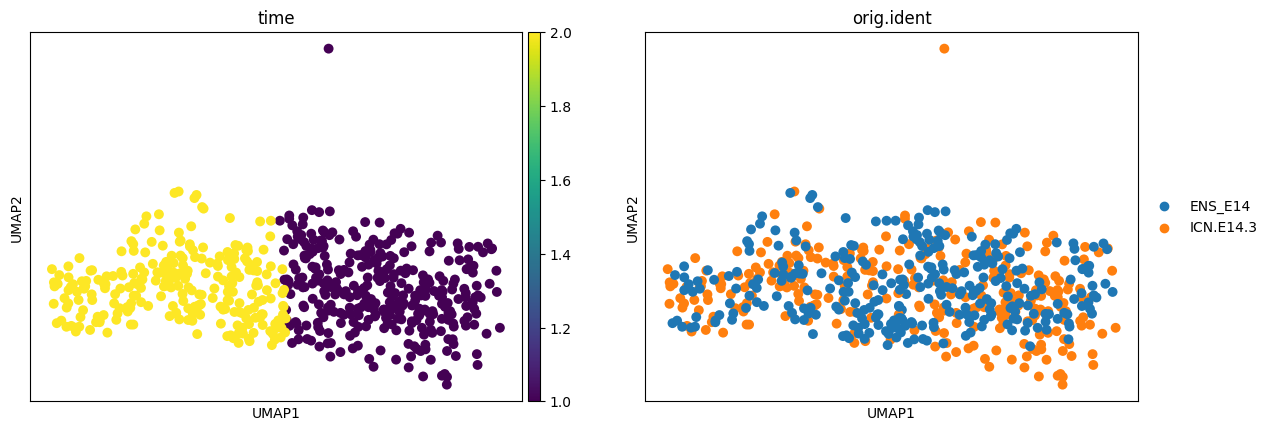

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(334, 260)].                                    


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


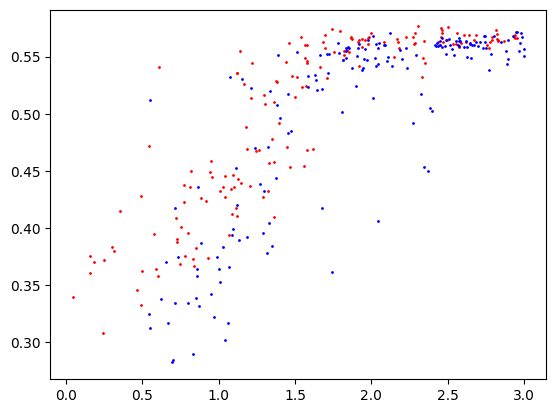

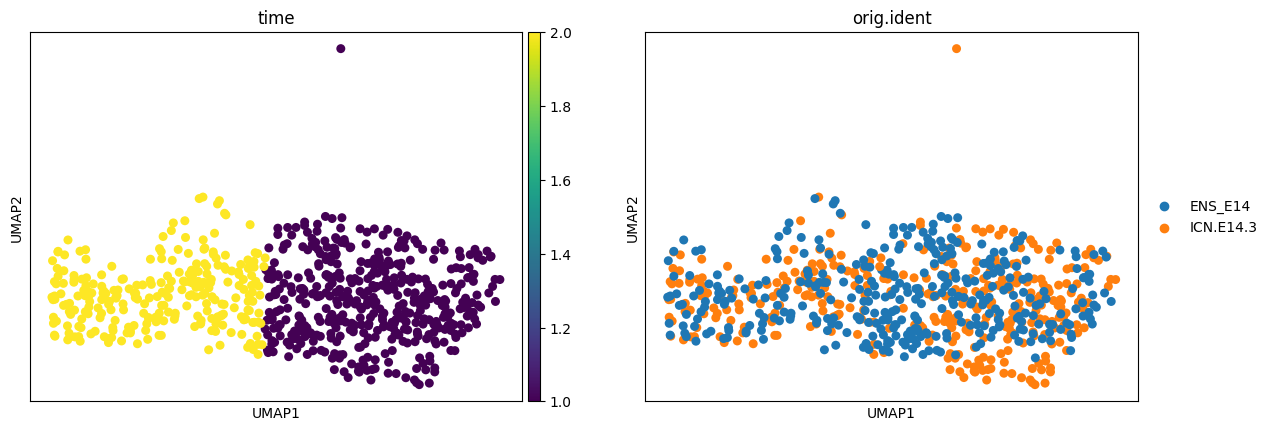

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(442, 274)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


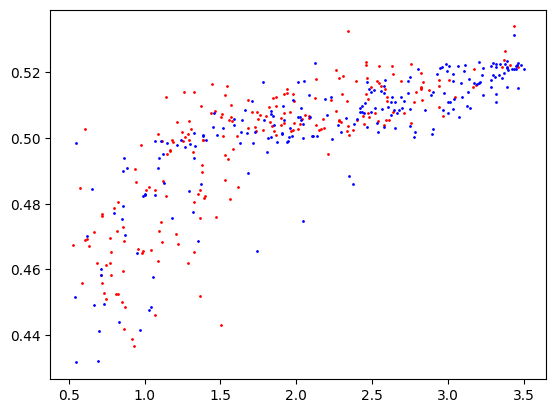

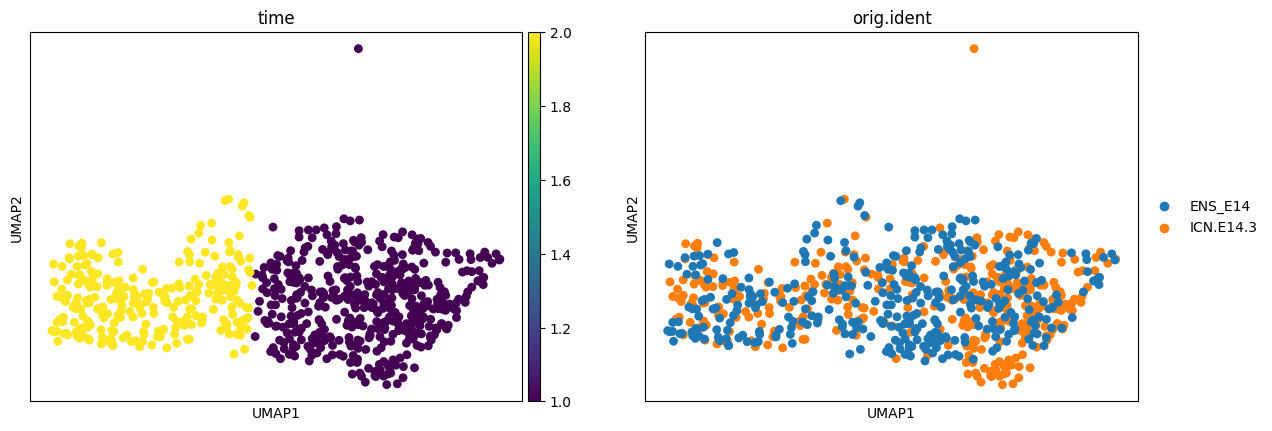

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(460, 278)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


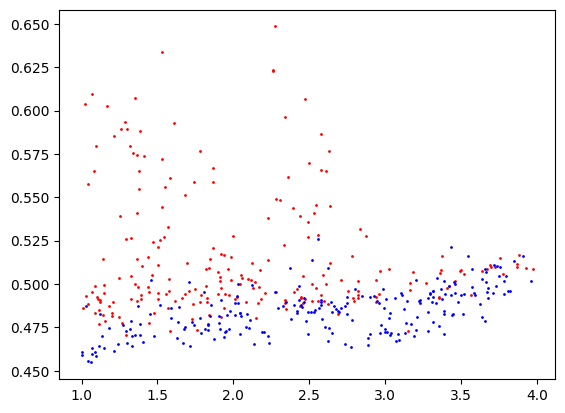

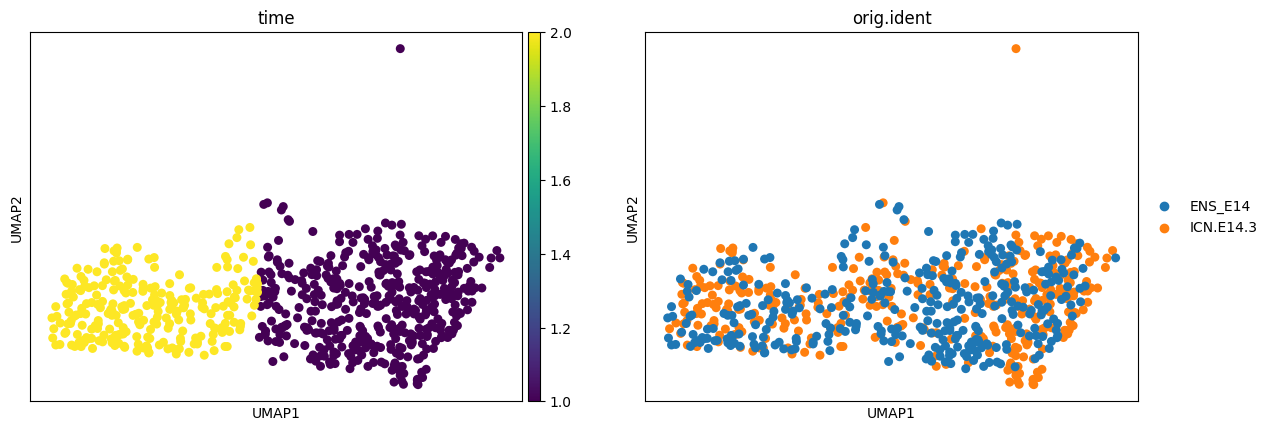

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(454, 264)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


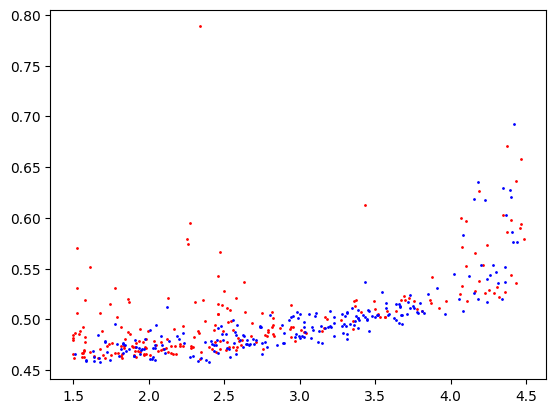

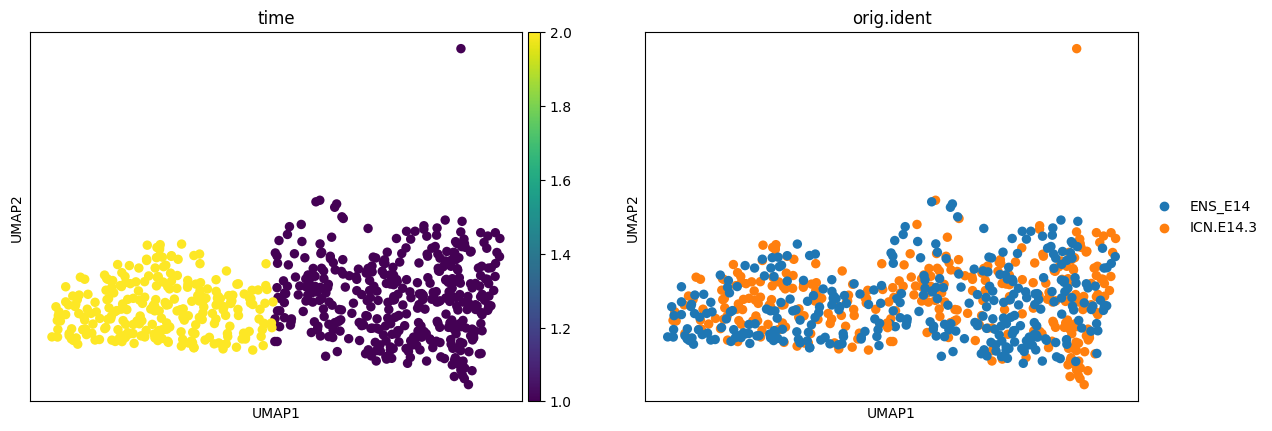

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(392, 258)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


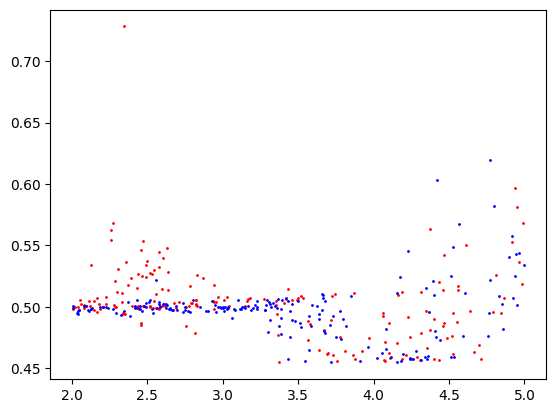

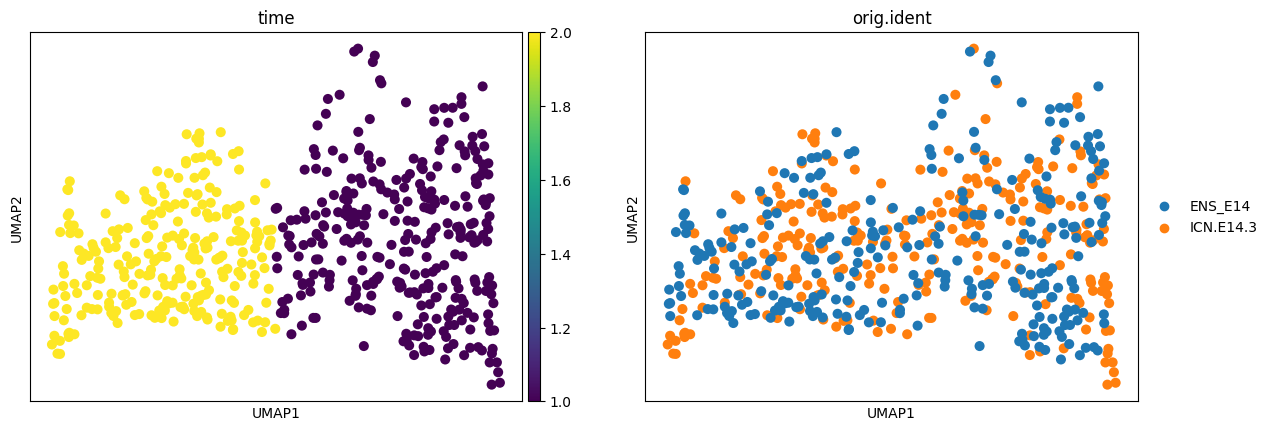

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(312, 260)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


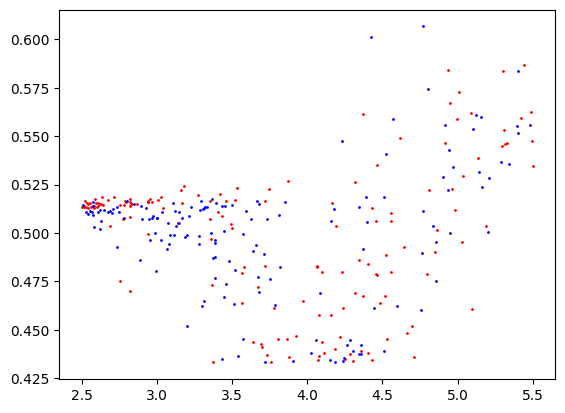

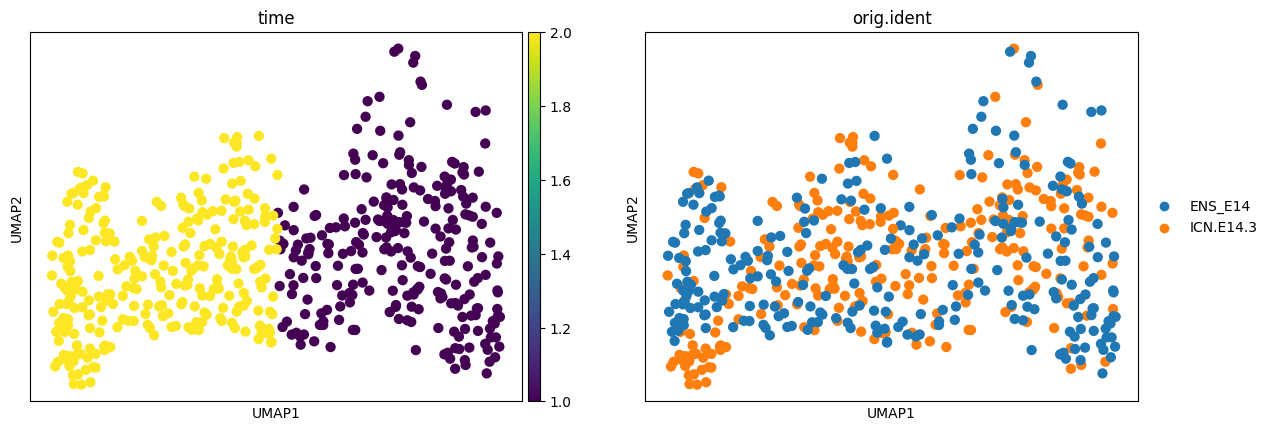

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(260, 284)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


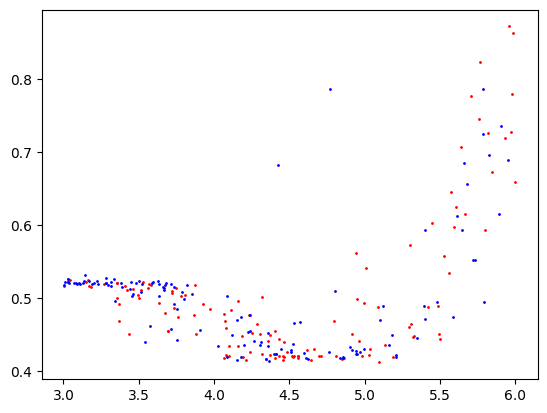

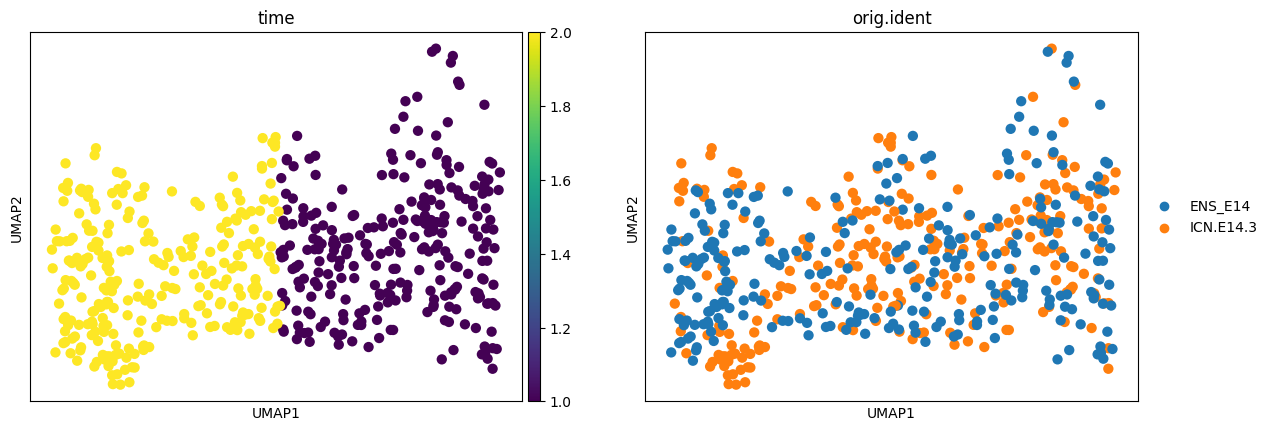

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(274, 270)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


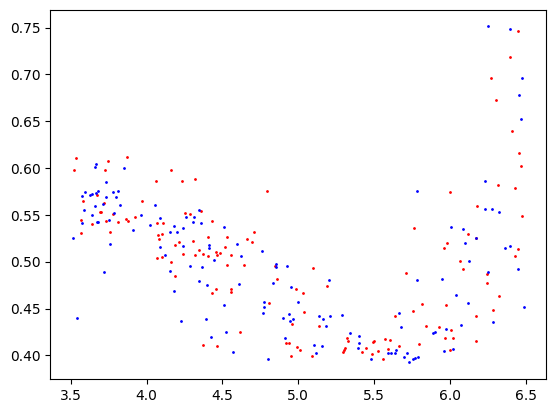

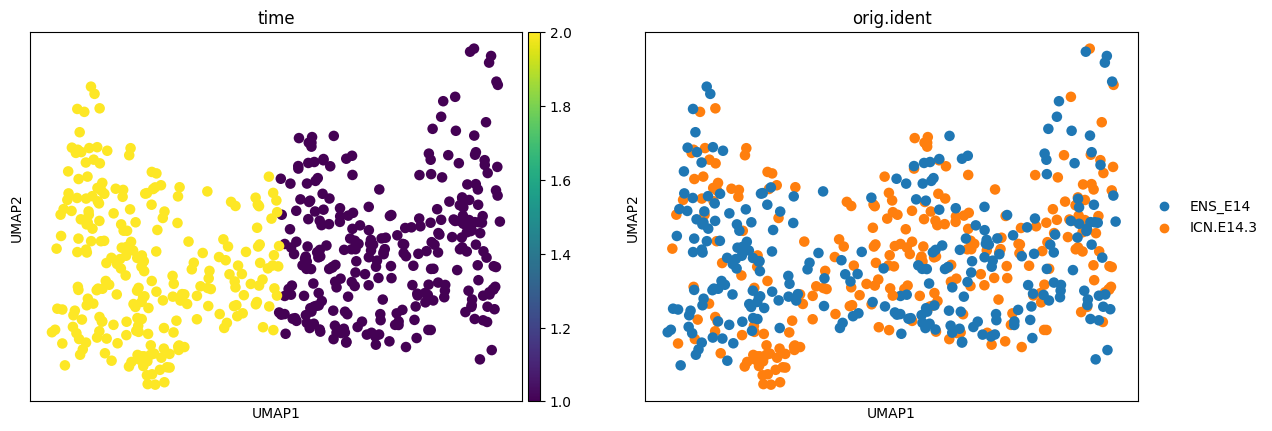

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(278, 244)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


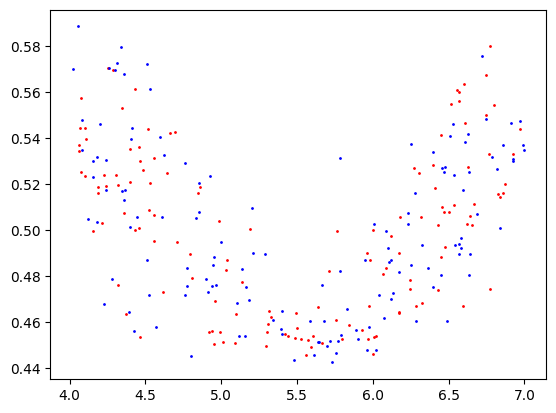

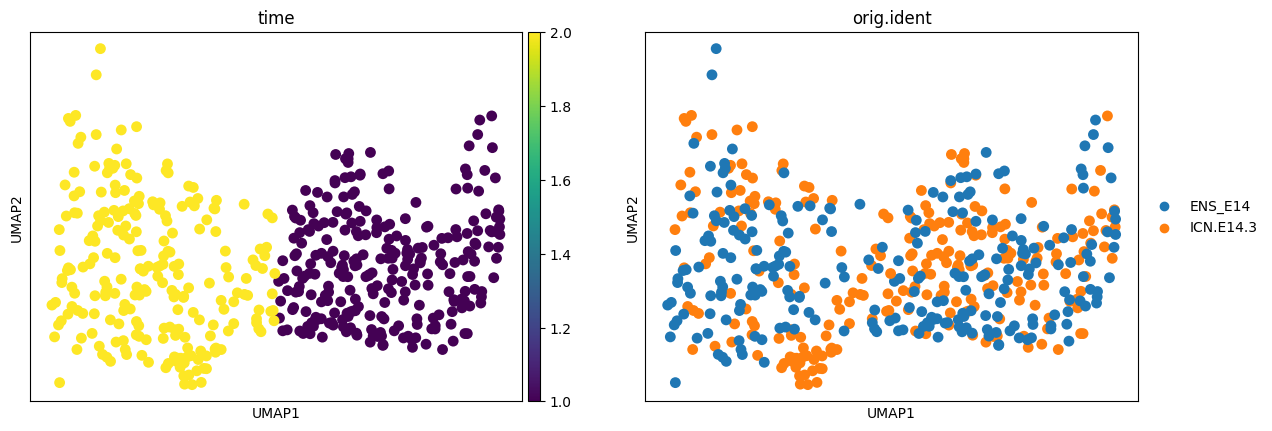

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(264, 230)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


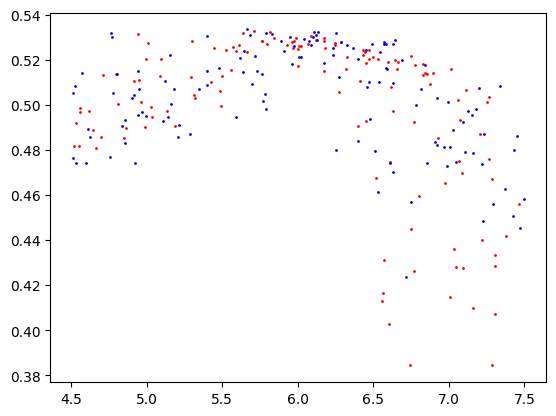

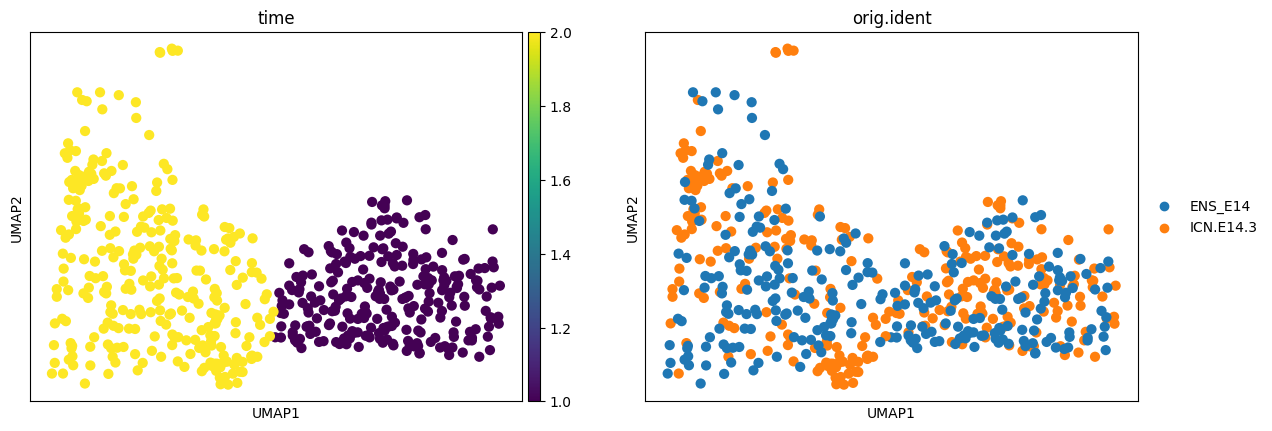

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(258, 294)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


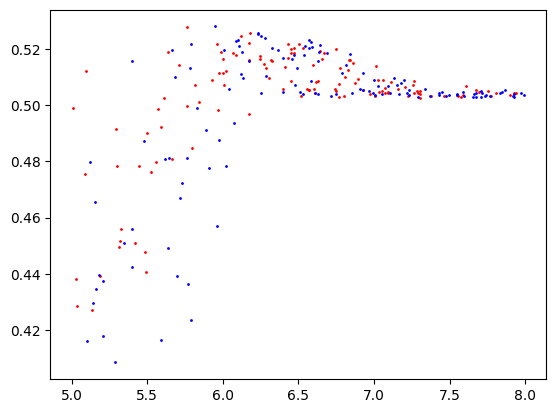

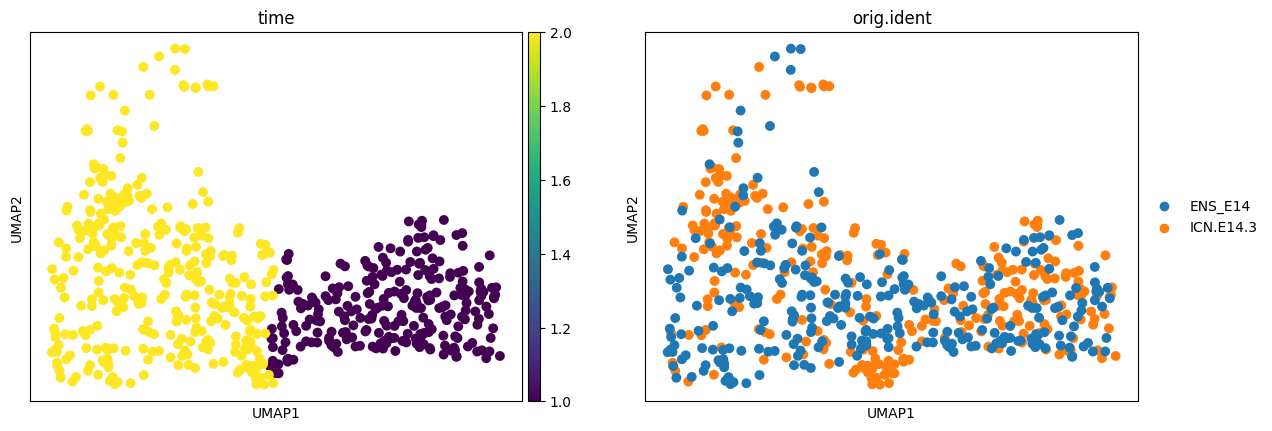

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(260, 334)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


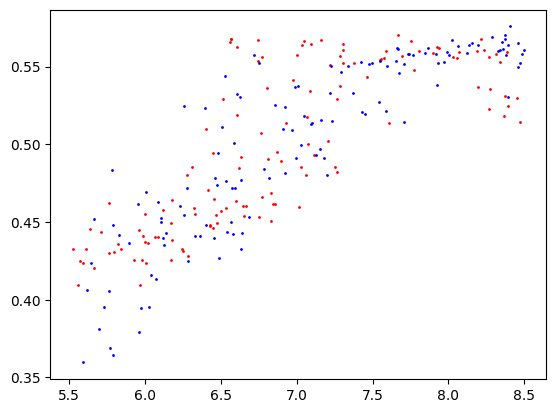

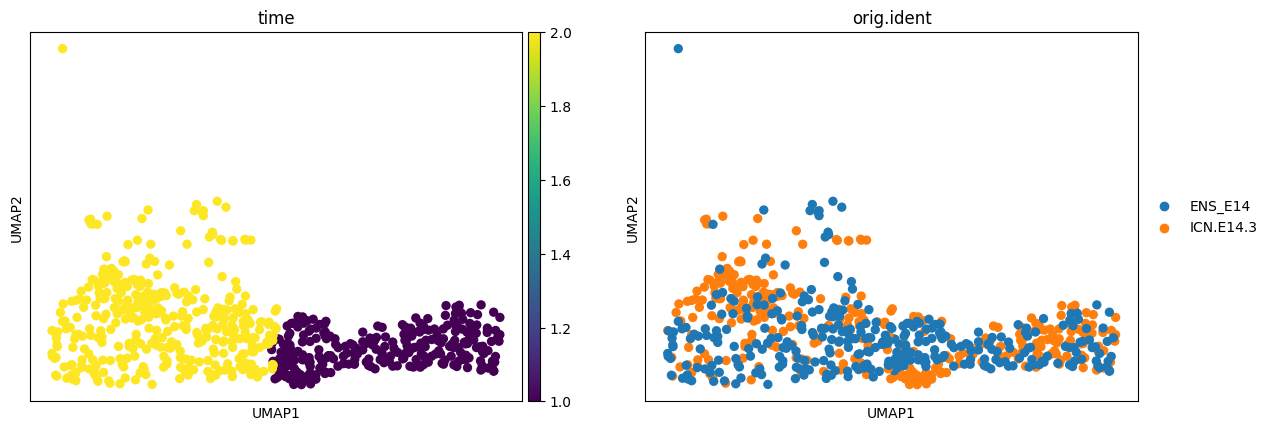

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(284, 380)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


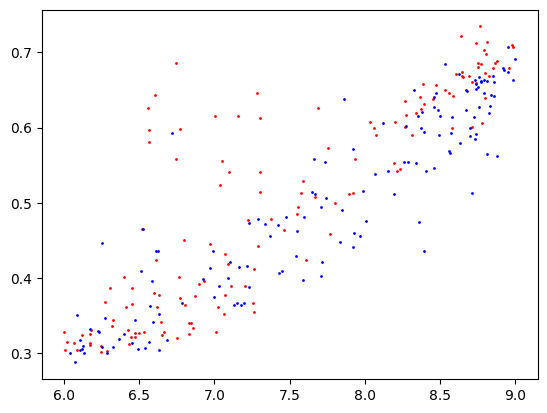

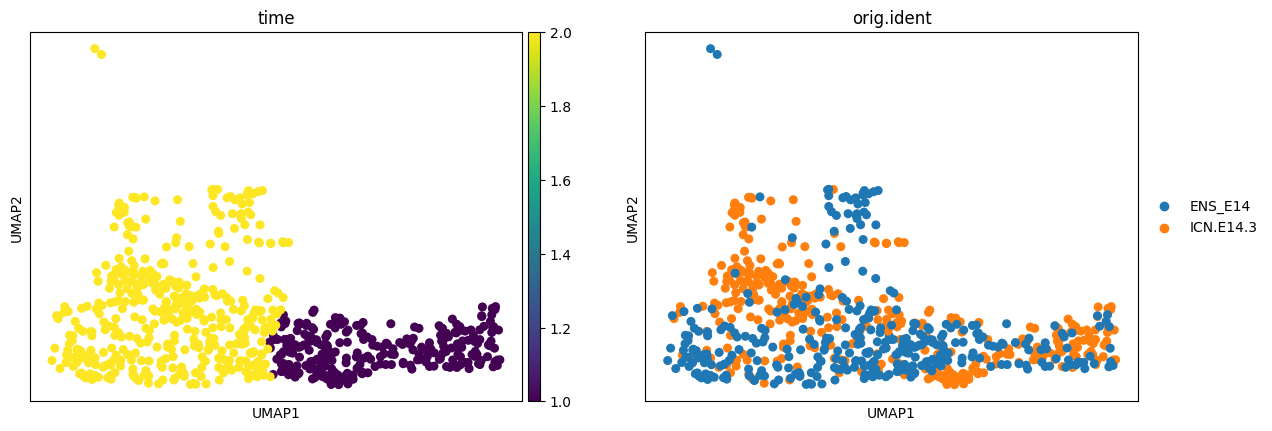

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(270, 442)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


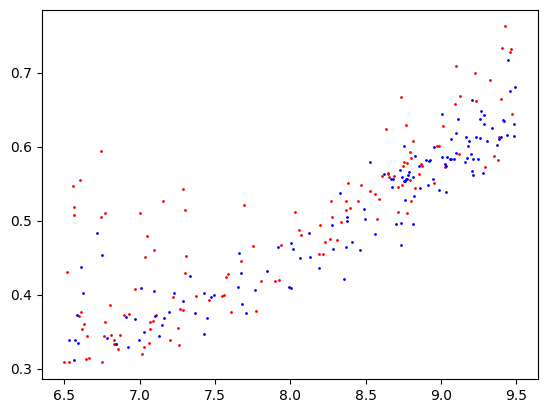

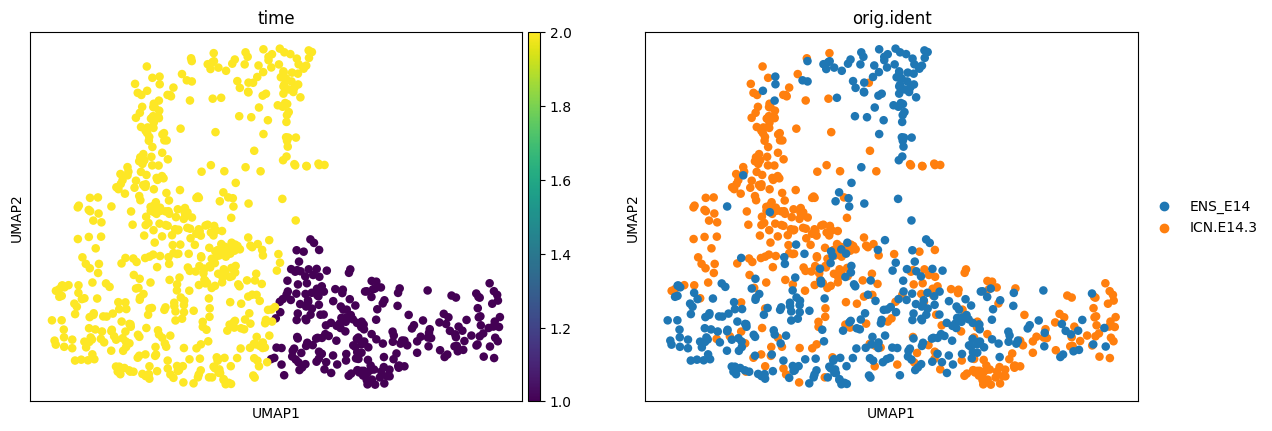

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(244, 546)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


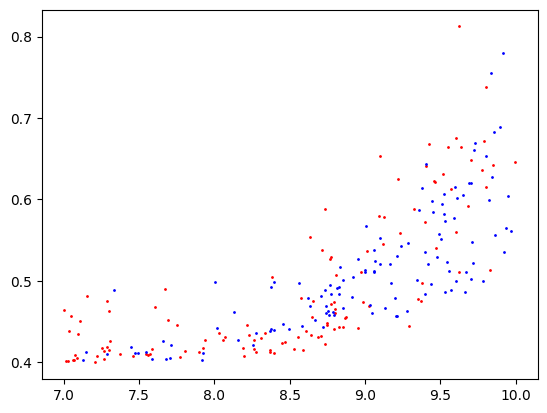

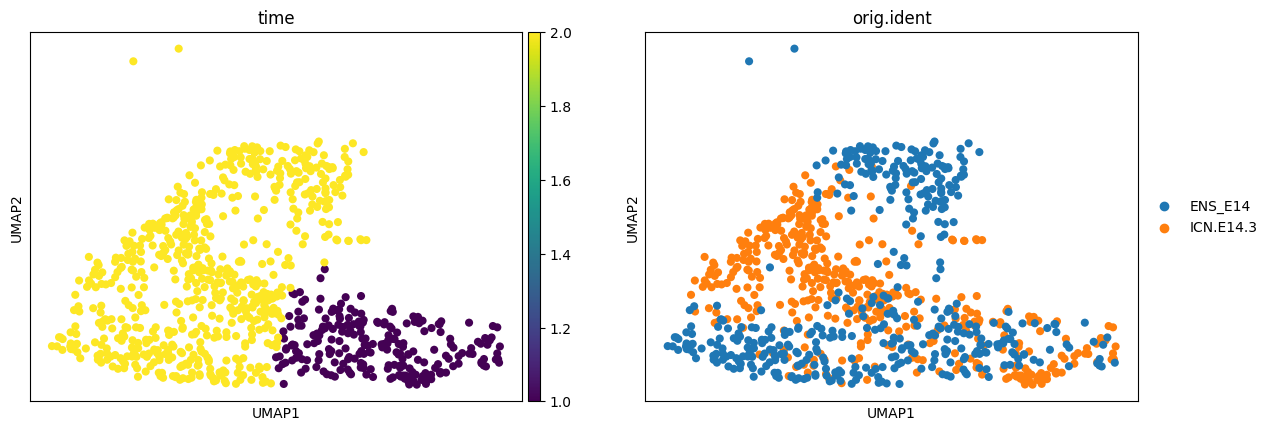

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(230, 650)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


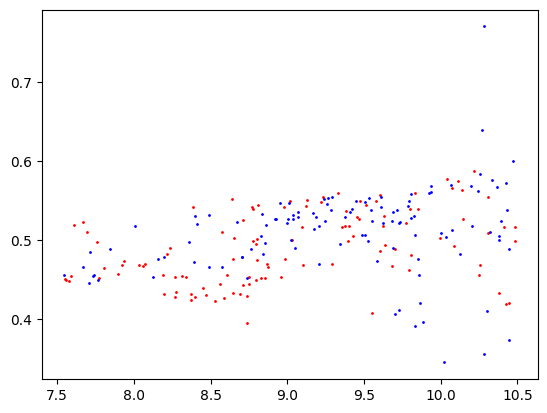

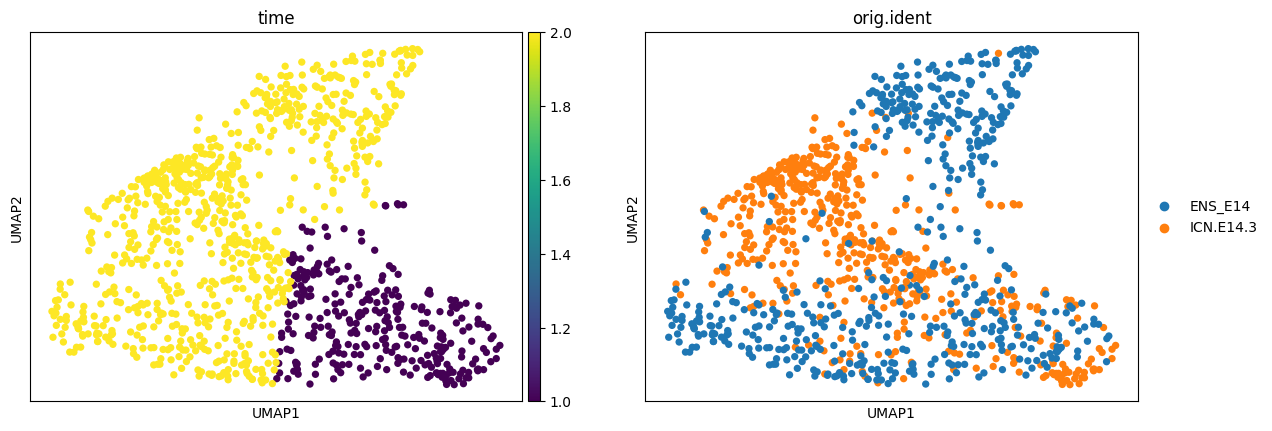

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(294, 788)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


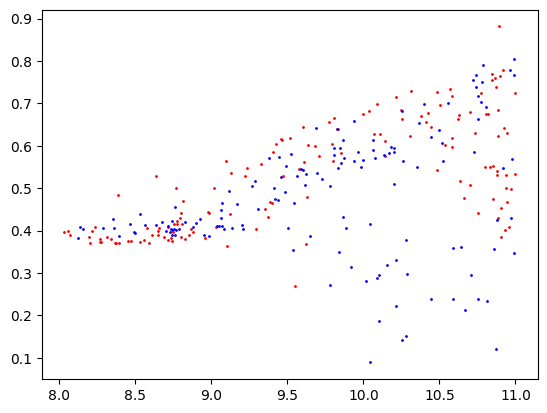

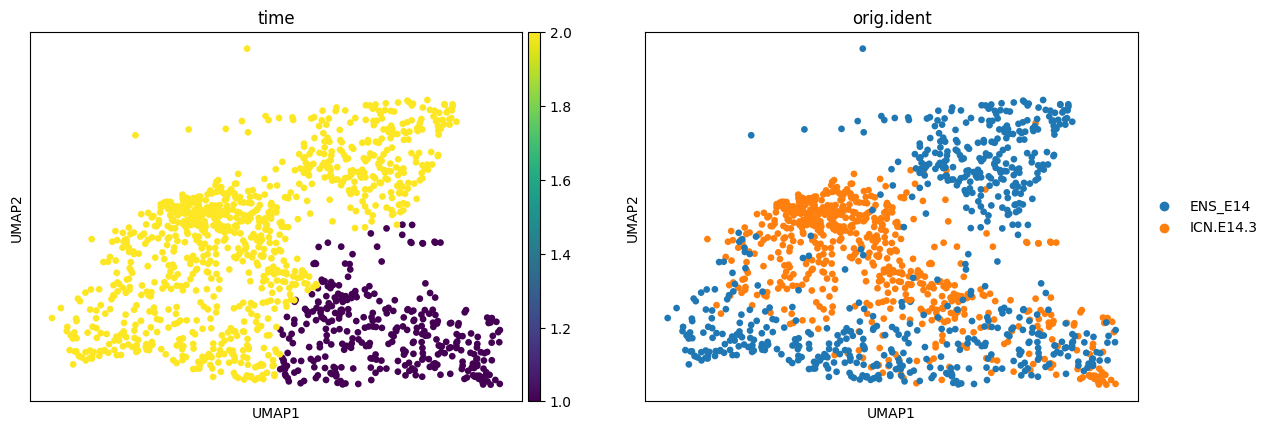

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(334, 946)].                                    


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


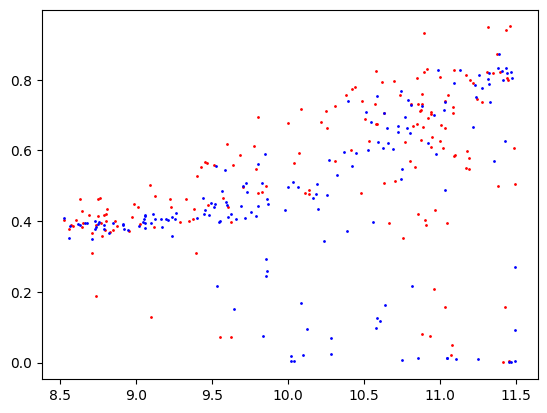

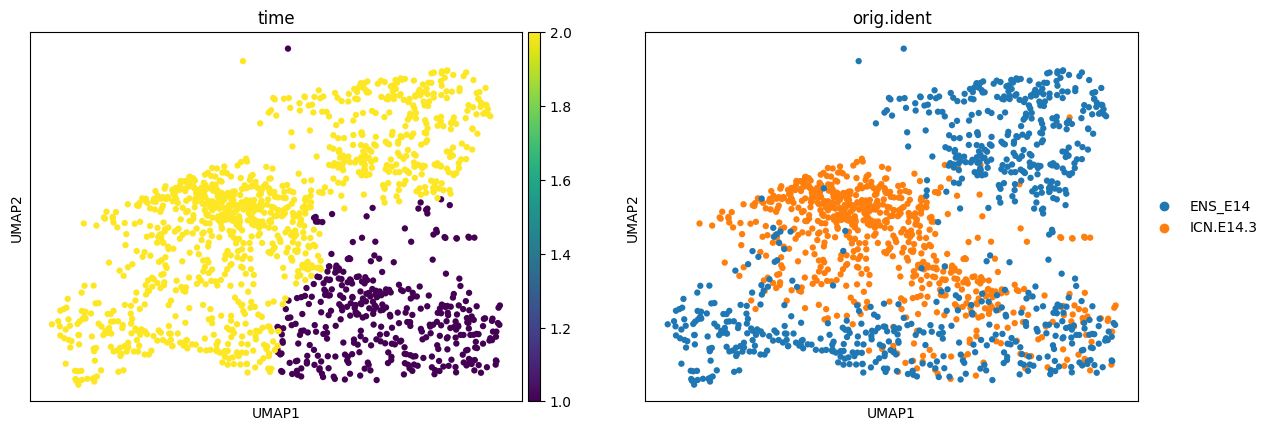

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(380, 1064)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


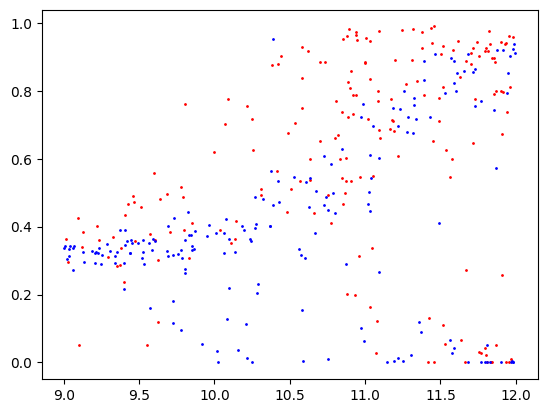

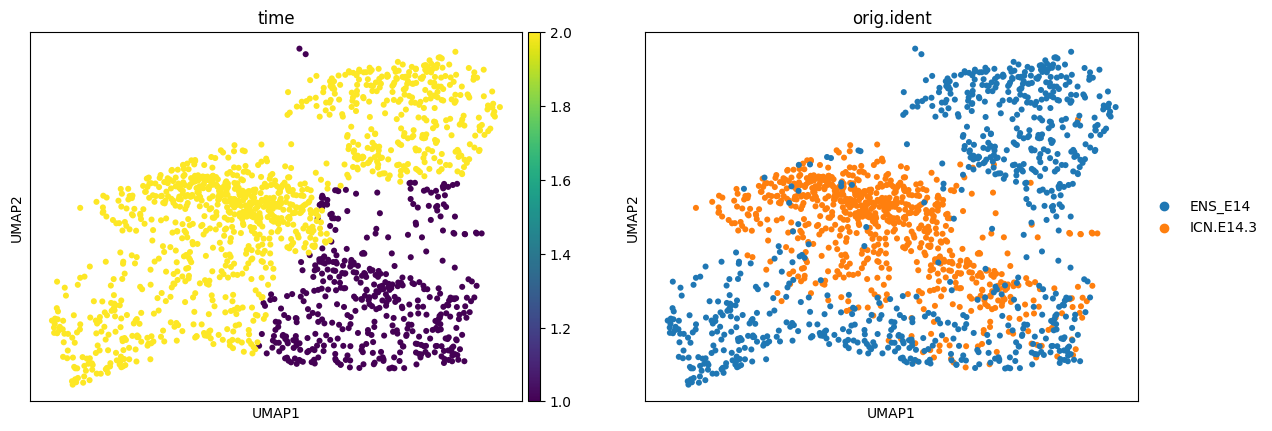

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(442, 1140)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


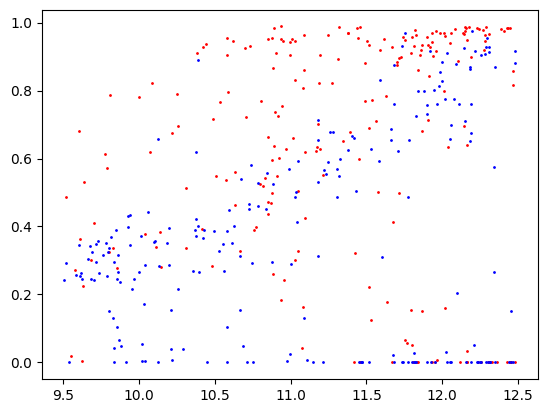

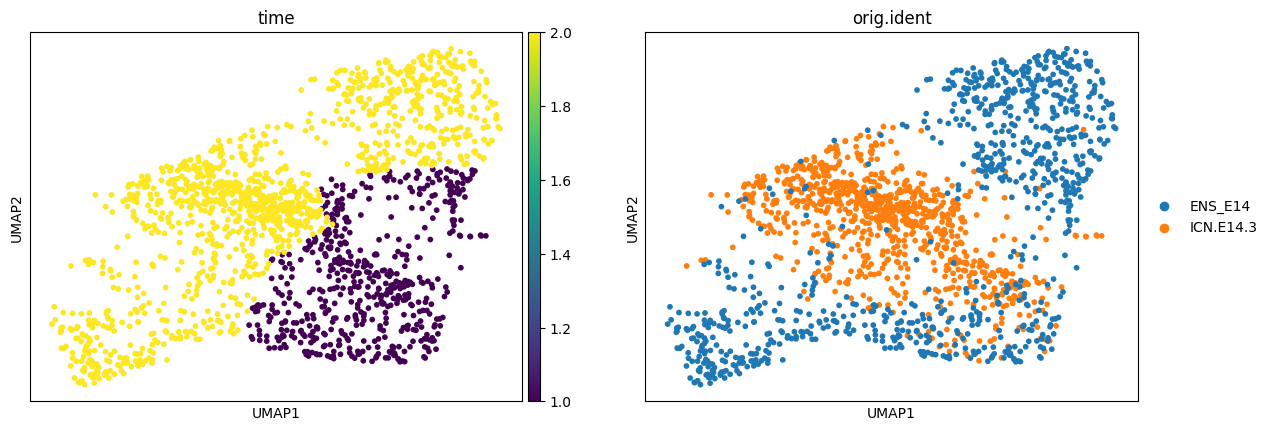

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(546, 1208)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


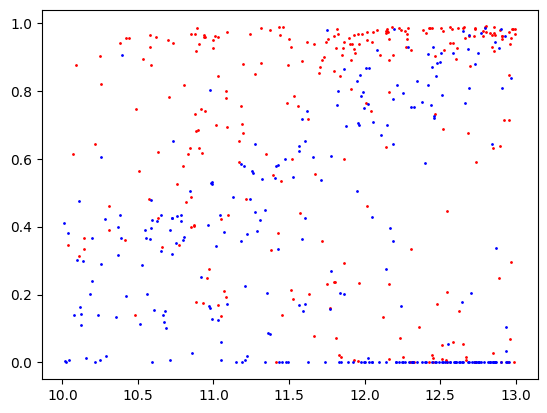

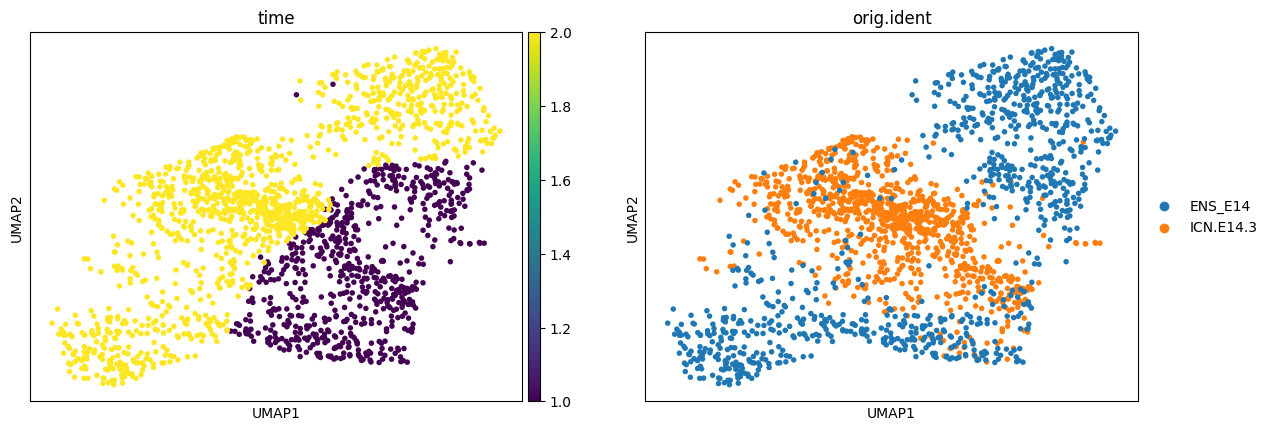

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(650, 1254)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


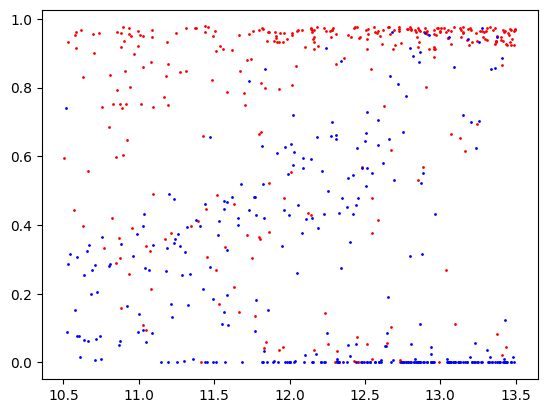

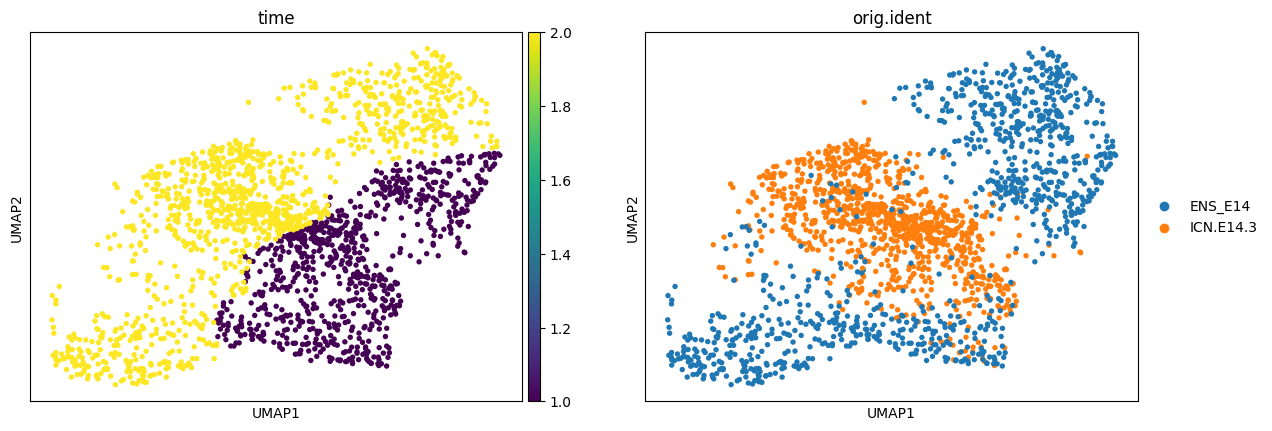

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(788, 1194)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


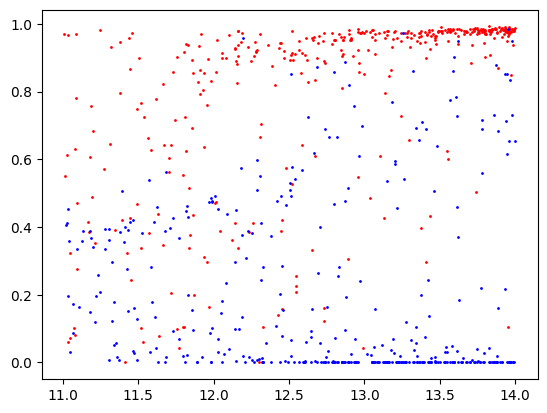

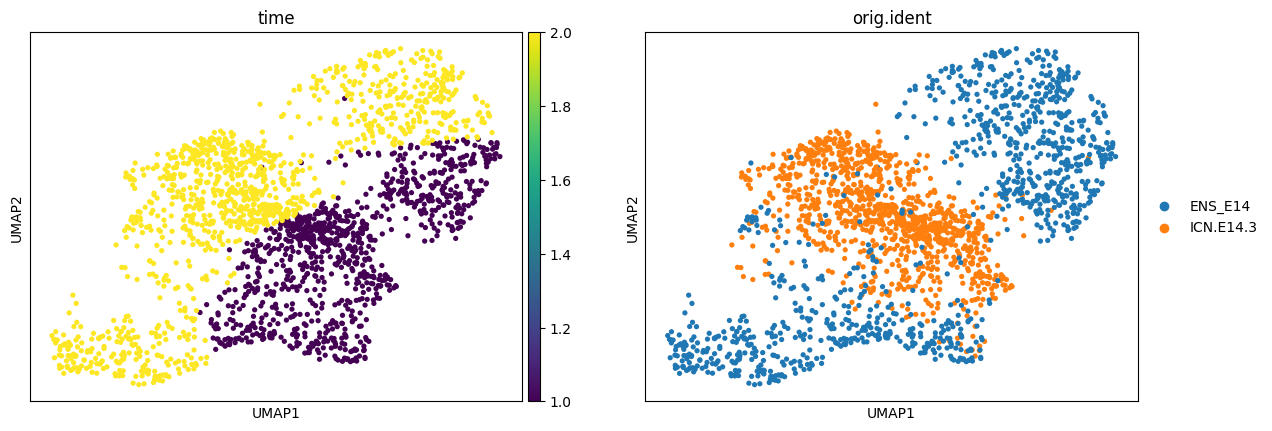

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(946, 1154)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


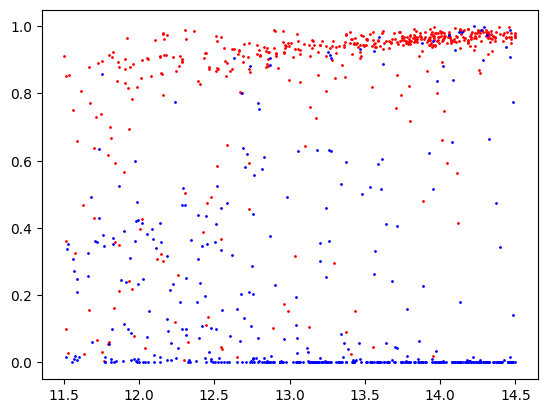

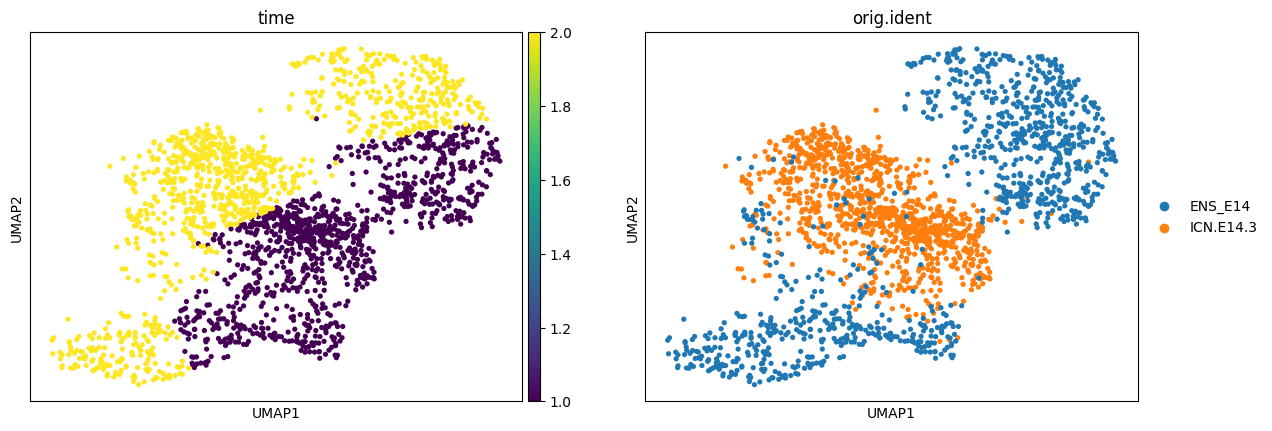

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1064, 1038)].                                  


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


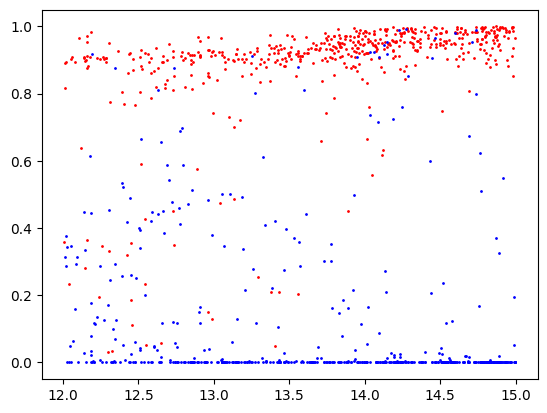

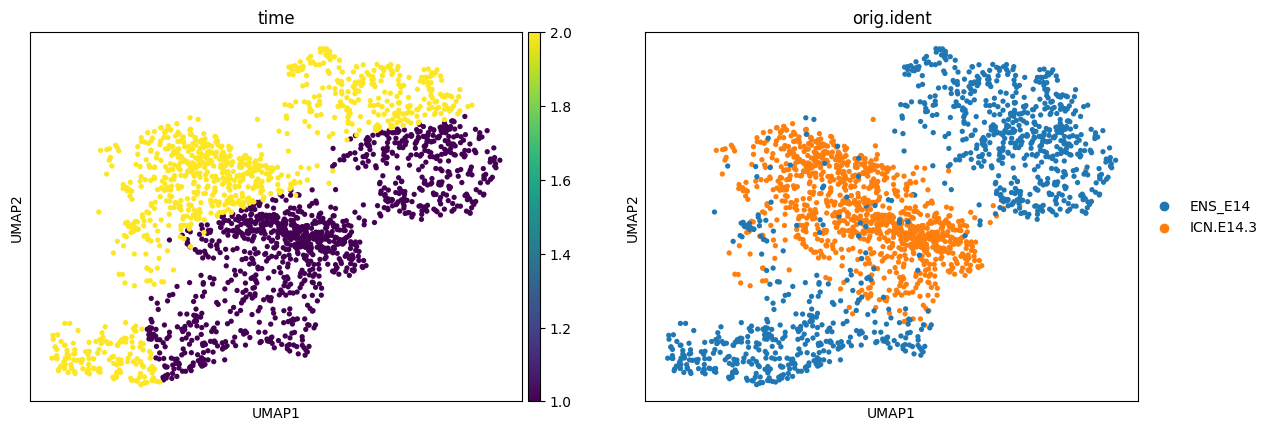

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1140, 938)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


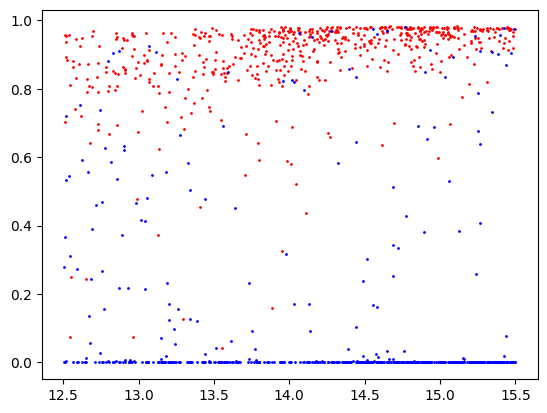

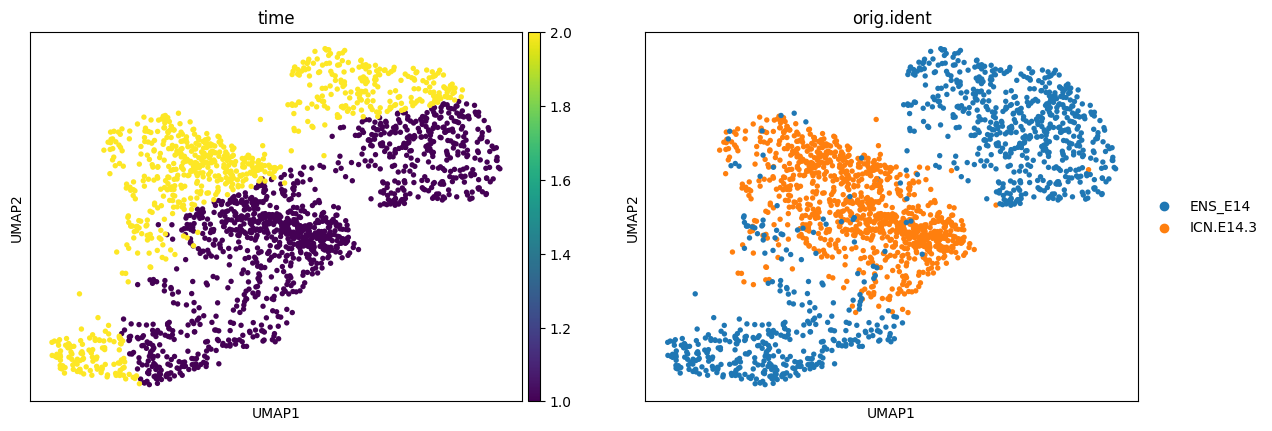

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1208, 778)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/wot/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


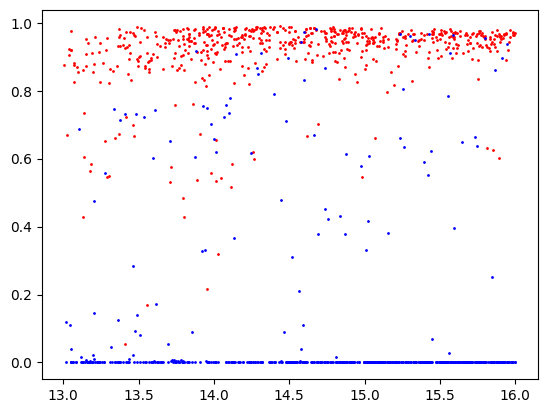

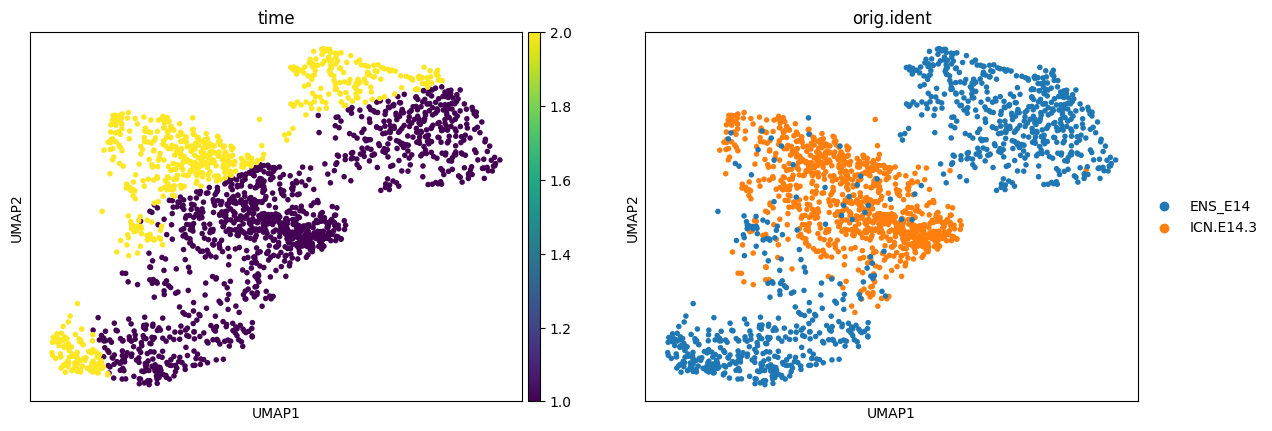

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1254, 632)].                                   


/tmp/ipykernel_208372/2595316564.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
/tmp/ipykernel_208372/2595316564.py:57: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]


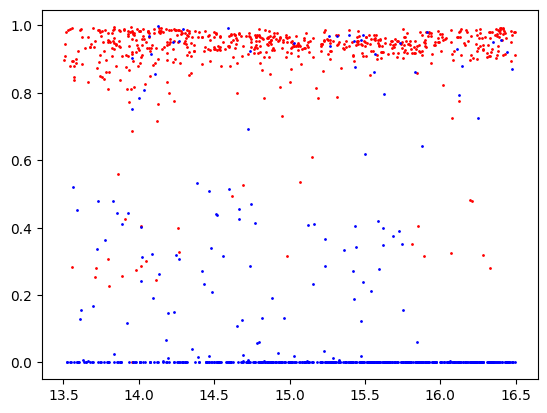

In [7]:
for i in range(len(adata_list) - 1 - int(dist_t/delta_t)):
    adata_0 = adata_list[i].copy()
    adata_0.obs["time"] = 1
    adata_1 = adata_list[i+int(dist_t/delta_t)].copy()
    adata_1.obs["time"] = 2
    
    adata_moscot = ad.concat([adata_0, adata_1])
    sc.pl.umap(adata_moscot, color=["time", "orig.ident"])
    
    # run moscot, and compute a single transport map
    tp0 = TemporalProblem(adata_moscot)
    use_rep = "X_gene"
    time_key = "time"
    tp0 = tp0.prepare(time_key = time_key, joint_attr = use_rep)
    
    import networkx as nx
    dfs = {}
    batch_column = time_key
    unique_batches = [1, 2]
    for j in range(len(unique_batches) - 1):
        batch1 = unique_batches[j]
        batch2 = unique_batches[j + 1]
    
        indices = np.where(
            (adata_moscot.obs[batch_column] == batch1) | (adata_moscot.obs[batch_column] == batch2)
        )[0]
        adata_subset = adata_moscot[indices]
        sc.pp.neighbors(adata_subset, use_rep=use_rep, n_neighbors=30)
        G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
        assert nx.is_connected(G)
    
        dfs[(batch1, batch2)] = pd.DataFrame(
            index=adata_subset.obs_names,
            columns=adata_subset.obs_names,
            data=adata_subset.obsp["connectivities"].todense().astype("float"),
        )

    tp0[1,2].set_graph_xy((dfs[1,2]).astype("float"), t=100.0) # could be varied
    tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7)
    transX = tp0.solutions[(1, 2)]._output.matrix
    transX = transX / np.sum(transX, axis=1).reshape((-1,1))
    tmap_annotated = ad.AnnData(np.array(transX))
    tmap_annotated.obs.index = adata_0.obs.index
    tmap_annotated.var.index = adata_1.obs.index


    # summarize prob
    cell_names_1_organ1 = adata_1.obs.index[adata_1.obs["orig.ident"] == organ_1]
    cell_names_1_organ2 = adata_1.obs.index[adata_1.obs["orig.ident"] == organ_2]
    tmap_annotated.obs["prob_organ1"] = np.sum(tmap_annotated[:,cell_names_1_organ1].X, axis=1)
    tmap_annotated.obs["prob_organ2"] = np.sum(tmap_annotated[:,cell_names_1_organ2].X, axis=1)
    adata_0_organ1 = adata_0[adata_0.obs["orig.ident"] == organ_1, :]
    adata_0_organ2 = adata_0[adata_0.obs["orig.ident"] == organ_2, :]
    
    adata_0_organ1.obs["prob_organ1"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ1"]
    adata_0_organ1.obs["prob_organ2"] = tmap_annotated[adata_0_organ1.obs.index, :].obs["prob_organ2"]
    adata_0_organ2.obs["prob_organ1"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ1"]
    adata_0_organ2.obs["prob_organ2"] = tmap_annotated[adata_0_organ2.obs.index, :].obs["prob_organ2"]
    
    plt.scatter(x = adata_0_organ1.obs["pseudotime1to4"], y = adata_0_organ1.obs["prob_organ1"], c="red", s=1)
    plt.scatter(x = adata_0_organ2.obs["pseudotime1to4"], y = adata_0_organ2.obs["prob_organ1"], c="blue", s=1)
    
    save_path = "/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_trajectory_fate_prob_moscot/wot_res_H_G"
    adata_0_organ1.write(save_path + "/adata_0_organ1_ot_"+str(i)+".h5ad")
    adata_0_organ2.write(save_path + "/adata_0_organ2_ot_"+str(i)+".h5ad")

In [8]:
n_res = len(adata_list)
n_res

35

In [9]:
## organ 1
n_res = 35
dist_t = 3
delta_t = 0.5

adata_list = []
for i in range(n_res - 1 - int(dist_t/delta_t)):
    save_path = "/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_trajectory_fate_prob_moscot/wot_res_H_G"
    adata_0_organ1 = sc.read_h5ad(save_path + "/adata_0_organ1_ot_"+str(i)+".h5ad")
    adata_list.append(adata_0_organ1.copy())

for i in range(n_res - 1 - int(dist_t/delta_t)):
    ad = adata_list[i].copy()
    ad.obs["wot_count"] = 1.
    if i == 0:
        prob_res = ad.obs
    else:
        shared_cells = (ad.obs.index).intersection(prob_res.index)
        unique_cells = (ad.obs.index).difference(prob_res.index)

        prob_res["prob_organ1"][shared_cells] = np.array(prob_res["prob_organ1"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ1"])
        prob_res["prob_organ2"][shared_cells] = np.array(prob_res["prob_organ2"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ2"])
        prob_res["wot_count"][shared_cells] = prob_res["wot_count"][shared_cells] + 1

        prob_res = pd.concat([prob_res, ad[unique_cells, :].obs])

prob_res["prob_organ1"] = prob_res["prob_organ1"] / prob_res["wot_count"]
prob_res["prob_organ2"] = prob_res["prob_organ2"] / prob_res["wot_count"]
prob_res_organ1 = prob_res.copy()

/tmp/ipykernel_208372/2885871320.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prob_res["prob_organ1"][shared_cells] = np.array(prob_res["prob_organ1"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ1"])
/tmp/ipykernel_208372/2885871320.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prob_res["prob_organ2"][shared_cells] = np.array(prob_res["prob_organ2"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ2"])
/tmp/ipykernel_208372/2885871320.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https:

In [10]:
## organ 2
n_res = 35
dist_t = 3
delta_t = 0.5

adata_list = []
for i in range(n_res - 1 - int(dist_t/delta_t)):
    save_path = "/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_trajectory_fate_prob_moscot/wot_res_H_G"
    adata_0_organ2 = sc.read_h5ad(save_path + "/adata_0_organ2_ot_"+str(i)+".h5ad")
    adata_list.append(adata_0_organ2.copy())

for i in range(n_res - 1 - int(dist_t/delta_t)):
    # print(i)
    ad = adata_list[i].copy()
    ad.obs["wot_count"] = 1.
    if i == 0:
        prob_res = ad.obs
    else:
        shared_cells = (ad.obs.index).intersection(prob_res.index)
        unique_cells = (ad.obs.index).difference(prob_res.index)

        prob_res["prob_organ1"][shared_cells] = np.array(prob_res["prob_organ1"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ1"])
        prob_res["prob_organ2"][shared_cells] = np.array(prob_res["prob_organ2"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ2"])
        prob_res["wot_count"][shared_cells] = prob_res["wot_count"][shared_cells] + 1

        prob_res = pd.concat([prob_res, ad[unique_cells, :].obs])

prob_res["prob_organ1"] = prob_res["prob_organ1"] / prob_res["wot_count"]
prob_res["prob_organ2"] = prob_res["prob_organ2"] / prob_res["wot_count"]
prob_res_organ2 = prob_res.copy()

/tmp/ipykernel_208372/3795846375.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prob_res["prob_organ1"][shared_cells] = np.array(prob_res["prob_organ1"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ1"])
/tmp/ipykernel_208372/3795846375.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prob_res["prob_organ2"][shared_cells] = np.array(prob_res["prob_organ2"][shared_cells]) + np.array(ad[shared_cells, :].obs["prob_organ2"])
/tmp/ipykernel_208372/3795846375.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https:

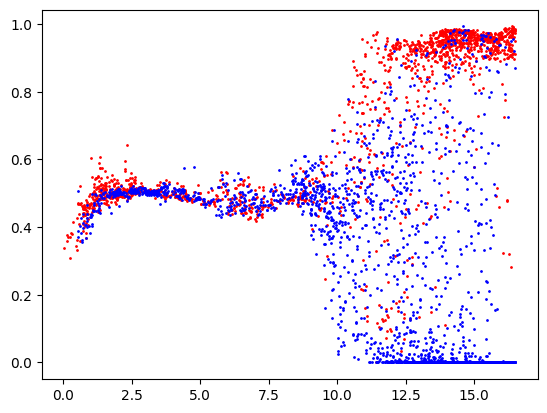

In [11]:
plt.scatter(x = prob_res_organ1["pseudotime1to4"], y = prob_res_organ1["prob_organ1"], c="red", s=1)
plt.scatter(x = prob_res_organ2["pseudotime1to4"], y = prob_res_organ2["prob_organ1"], c="blue", s=1)

In [12]:
save_path = "/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_trajectory_fate_prob_moscot/prob_res"
prob_res_organ1.to_csv(save_path + "/prob_H_G_organ1.csv")
prob_res_organ2.to_csv(save_path + "/prob_H_G_organ2.csv")